# 5.1 - Files (9.2, 9.3, 9.4)
***

* A **text file** is a sequence of characters
* A **binary file** (for images, videos and more) is a sequence of bytes
* First character in a text file or byte in a binary file is located at position 0
    * In a file of **_n_** characters or bytes, the highest position number is **_n_ – 1**
* For each file you **open**, Python creates a **file object** that you’ll use to interact with the file

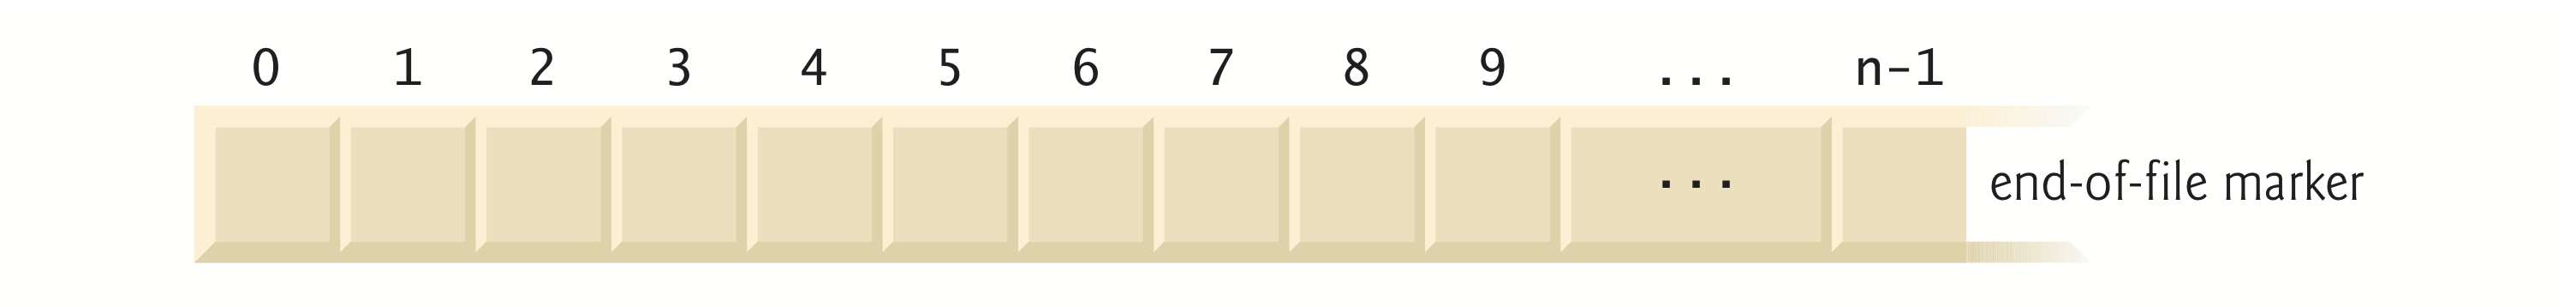

### End of File
* Every operating system provides a mechanism to denote the end of a file
    * Some use an **end-of-file marker**
    * Others maintain a count of the total characters or bytes in the file
    * Programming languages hide these operating-system details from you

### Standard File Objects
* When a Python program begins execution, it creates three **standard file objects**:
    * **`sys.stdin`**—the **standard input file object**
    * **`sys.stdout`**—the **standard output file object**, and
    * **`sys.stderr`**—the **standard error file object**.
* Though considered file objects, they do not read from or write to files by default
    * The `input` function implicitly uses `sys.stdin` to get user input from the keyboard
    * Function `print` implicitly outputs to `sys.stdout`, which appears in the command line
    * Python implicitly outputs program errors and tracebacks to `sys.stderr`, which also appears in the command line
* Import the `sys` module if you need to refer to these objects explicitly in your code&mdash;this is rare

## 9.3 Text-File Processing
* Here, we'll create a simple text file that might be used by an accounts-receivable system to track the money owed by a company’s clients
* We’ll then read that text file to confirm that it contains the data
* For each client, we’ll store
    * client’s account number
    * last name
    * account balance owed to the company
* These data fields represent a client **record**
* Programmers must structure files to meet their applications’ requirements

### 9.3.1 Writing to a Text File: Introducing the `with` Statement
* Many applications _acquire_ resources
    * files, network connections, database connections and more
* Should _release_ resources as soon as they’re no longer needed
* Ensures that other applications can use the resources
* `with` statement
    * Acquires a resource and assigns its corresponding object to a variable
    * Allows the application to use the resource via that variable
    * Calls the resource object’s **`close` method** to release the resource

In [ ]:
"""Create the Accounts file"""
with open("accounts.txt", mode="w") as accounts:
  accounts.write("100 Jones 24.98\n")
  accounts.write("200 Doe 345.67\n")
  accounts.write("300 White 0.00\n")
  accounts.write("400 Stone -42.16\n")

* Can also **write to a file with `print`**, which **automatically outputs a `\n`**, as in
```python
print('100 Jones 24.98', file=accounts)
```

### Built-In Function `open`
* Opens the file `accounts.txt` and associates it with a file object
* `mode` argument specifies the **file-open mode**
    * whether to open a file for reading from the file, for writing to the file or both.
* Mode `'w'` opens the file for _writing_, creating the file if it does not exist
* If you do not specify a path to the file, Python creates it in the current folder
* **Be careful**—opening a file for writing _deletes_ all the existing data in the file
* By convention, the **`.txt` file extension** indicates a plain text file

### Writing to the File
* `with` statement assigns the object returned by `open` to the variable `accounts` in the **`as` clause**
* `with` statement’s suite uses `accounts` to interact with the file
    * file object’s **`write` method** writes one record at a time to the file
* At the end of the `with` statement’s suite, the `with` statement _implicitly_ calls the file object’s **`close`** method to close the file

### 9.3.2 Reading Data from a Text File
* Let's read `accounts.txt` sequentially from beginning to end

In [ ]:
with open("accounts.txt", mode="r") as accounts:
  print(f"{'Account':<10}{'Name':<10}{'Balance':>10}")
  for record in accounts:
    account, name, balance = record.split()
    print(f"{account:<10}{name:<10}{balance:>10}")

Account   Name         Balance
100       Jones          24.98
200       Doe           345.67
300       White           0.00
400       Stone         -42.16


### 9.3.2 Reading Data from a Text File (cont.)
* If the contents of a file should not be modified, open the file for reading only
    * Prevents program from accidentally modifying the file
* Iterating through a file object, reads one line at a time from the file and returns it as a string
* For each `record` (that is, line) in the file, string method `split` returns tokens in the line as a list
    * We unpack into the variables `account`, `name` and `balance`

### File Method `readlines`
* File object’s **`readlines`** method also can be used to read an _entire_ text file
* Returns each line as a string in a list of strings
* For small files, this works well, but iterating over the lines in a file object, as shown above, can be more efficient
    * Enables your program to process each text line as it’s read, rather than waiting to load the entire file

### Seeking to a Specific File Position
* While reading through a file, the system maintains a **file-position pointer** representing the location of the next character to read
* To process a file sequentially from the beginning _several times_ during a program’s execution, you must reposition the file-position pointer to the beginning of the file
    * Can do this by closing and reopening the file, or
    * by calling the file object’s **`seek`** method, as in
```python
file_object.seek(0)
```
* The latter approach is faster

## Appending to a Text File

* If we just want to add more data to a text file, we can open the file in **append** mode.
* Append mode is specified as `mode="a"` inside the `open` function.
* In this case, the file is opened with the position pointer automatically set to the last position.
* Any data that is written, will be placed at the end of the file.

In [ ]:
with open("accounts.txt", mode="a") as accounts:
  accounts.write("600 Lang 90.45")

## 9.4 Updating Text Files
* Formatted data written to a text file cannot be modified without the risk of destroying other data
* If the name `'White'` needs to be changed to `'Williams'` in `accounts.txt`, the old name cannot simply be overwritten
* The original record for `White` is stored as
```python
300 White 0.00
```
* If you overwrite the name `'White'` with the name `'Williams'`, the record becomes
```python
300 Williams00
```
* The characters beyond the second “`i`” in `'Williams'` overwrite other characters in the line
* The problem is that records and their fields can vary in size

* To make the preceding name change, we can:
    * copy the records before `300 White 0.00` into a temporary file,
    * write the updated and correctly formatted record for account 300 to this file,
    * copy the records after `300 White 0.00` to the temporary file,
    * delete the old file and
    * rename the temporary file to use the original file’s name.
* Requires processing _every_ record in the file, even if you need to update only one record
    * More efficient when an application needs to update many records in one pass of the file

### Updating accounts`.txt`
* Update the `accounts.txt` file to change account 300’s name from `'White'` to `'Williams'` as described above:

In [ ]:
accounts = open("accounts.txt", mode="r")

In [ ]:
temp_file = open("temp_file.txt", mode="w")

In [ ]:
with accounts, temp_file:
  for record in accounts:
    account, name, balance = record.split()
    if account != "300":
      temp_file.write(record)
    else:
      new_record = " ".join([account, "Williams", balance])
      temp_file.write(new_record + "\n")

### Updating accounts`.txt` (cont.)
* This `with` statement manages two resource objects, specified in a comma-separated list after `with`
    * If the account is not `'300'`, we write `record` (which contains a newline) to `temp_file`
    * Otherwise, we assemble the new record containing `'Williams'` in place of  `'White'` and write it to the file

### `os` Module File-Processing Functions
* To complete the update, delete the old `accounts.txt` file, then rename `temp_file.txt` as `accounts.txt`

In [ ]:
import os

In [ ]:
os.remove("accounts.txt")

* Use the **`rename` function** to rename the temporary file as `'accounts.txt'`

In [ ]:
os.rename("temp_file.txt", "accounts.txt")

***
# CLASSWORK

1. **Fill-in**:
  * A file that ends with `.txt` is called a text file.
  * The in-built function open can be used to access/create a file object.
  * The code `open("file.txt", mode = "w")` opens `file.txt` in writing mode.
  * The code `open("file.txt", mode = "r")` opens `file.txt` in reading mode.
  * When opening a file in writing mode, all existing data is erased.  
  * The with suite implicitly releases resources once executed.

2. **Username Login System**: Complete the following steps:

  ### Creating a File

  * Open/create a file named `users.txt` in **write mode**.
  * Write the following three username-password pairs into the file (one per line):
   - `alice 1234`
   - `bob qwerty`
   - `carol abcd`

  ### Reading from a File
  * Open the file in **read mode**.
  * Print each username and password on a separate line, using `.split(' ')` to separate them.

  ### Appending to a File
  * Ask the user for a new username and password using `input()`.
  * Append the new user to the end of the file.
  * Print the updated contents of the file.

  ### Deleting from a File
  * Ask the user for a username to delete.
  * Read the current contents of `users.txt`.
  * Write all lines except the one with the matching username into a **new file** called `temp.txt`.
  * Use the `os` module to:
   - Delete `users.txt`
   - Rename `temp.txt` to `users.txt`

In [1]:
with open("users.txt", mode="w") as users:
  users.write("alice 1234\n")
  users.write("bob qwerty\n")
  users.write("carol abcd\n")

with open("users.txt", mode="r") as users:
  for record in users:
    name, idk = record.split()
    print(f"{name}: {idk}")

alice: 1234
bob: qwerty
carol: abcd


In [3]:
user = input("Enter username: ")
password = input("Enter password: ")

with open("users.txt", mode="a") as users:
  users.write(user + " " + password)

Enter username: alina
Enter password: cs171


In [4]:
user = input("Who should we delete: ")
users = open("users.txt", mode="r")
temp_file = open("temp_file.txt", mode="w")

with users, temp_file:
  for record in users:
    name, password = record.split()
    if name != user:
      temp_file.write(record)


Who should we delete: alice


In [5]:
import os

os.remove("users.txt")
os.rename("temp_file.txt", "users.txt")

3. **Advanced**: Encapsulate the above features into functions called:
  * `add_user(username, password)`: adds the username and password to the `users.txt` file.
  * `delete_user(username)`: deletes the user specified by the username from the file.
  * `authenticate(username, password)`: returns `True` if the username and password are found in the file.

4. **Advanced**: Complete the following:
  * Figure out how to save the `shakespeare.txt` file to your google colab local directory
  * Open `shakespeare.txt` in read mode and count:
    * the number of lines
    * the number of words

------
&copy;1992&ndash;2020 by Pearson Education, Inc. All Rights Reserved. This content is based on Chapter 5 of the book [**Intro to Python for Computer Science and Data Science: Learning to Program with AI, Big Data and the Cloud**](https://amzn.to/2VvdnxE).

DISCLAIMER: The authors and publisher of this book have used their
best efforts in preparing the book. These efforts include the
development, research, and testing of the theories and programs
to determine their effectiveness. The authors and publisher make
no warranty of any kind, expressed or implied, with regard to these
programs or to the documentation contained in these books. The authors
and publisher shall not be liable in any event for incidental or
consequential damages in connection with, or arising out of, the
furnishing, performance, or use of these programs.                  